In [26]:
import fastbook
fastbook.setup_book()
     

#hide
from fastbook import *
from fastai.vision.all import *

In [27]:
from duckduckgo_search import DDGS #DuckDuckGo has changed the api so we need to update 
from fastcore.all import *

def search_images(keywords, max_images=100):
    return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
import time, json

#NB: `search_images` depends on duckduckgo.com, which doesn't always return correct responses.
#    If you get a JSON error, just try running it again (it may take a couple of tries).
urls = search_images('bear photos', max_images=1)
urls[0]

'https://www.publicdomainpictures.net/pictures/240000/velka/grizzly-bear-portrait-1511961987XRY.jpg'

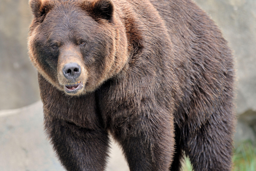

In [28]:
from fastai.vision.all import *
im = Image.open('images/bear.jpg')
im.to_thumb(256,256)

In [29]:
bear_types = 'cute','silly'
path = Path('cats')

In [30]:
for o in bear_types:
    dest = (path/o)
    try:
        dest.mkdir(exist_ok=False, parents=True)
    except:
        continue
    download_images(dest, urls=search_images(f'{o} orange cat'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

In [31]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

In [32]:
fns = get_image_files(path)
fns

(#232) [Path('cats/cute/00367f0a-f972-4dc3-b217-85d185115411.jpg'),Path('cats/cute/0151345f-d421-4f15-9832-fb0de299eef3.jpg'),Path('cats/cute/05db4fa9-1571-413e-8664-1b92904415bc.jpg'),Path('cats/cute/08d8122b-6fa9-4dd1-b38f-e9c55c3d7b63.jpg'),Path('cats/cute/094b313c-95c8-4c16-9102-dfc85df5d441.jpg'),Path('cats/cute/09b18083-ef02-4ed9-91ac-cec1f8f90111.jpg'),Path('cats/cute/0BD5ECA4-F846-44F0-8809-A023D505AE55.jpg'),Path('cats/cute/0c5a3527-64b6-4846-8e39-983109084f64.jpg'),Path('cats/cute/12f9e434-8b58-4b74-9e24-29c1496d213d.jpg'),Path('cats/cute/15d999c6-c267-4448-9746-e925891709ee.jpg'),Path('cats/cute/16b5d88a-5326-4a9f-bf81-b1ee6228c728.jpg'),Path('cats/cute/1944b0a5-63a9-4fc8-9801-67bcc85f7aea.jpg'),Path('cats/cute/1b5f99c2-c3d2-4451-88ab-86f2e53c71ba.jpg'),Path('cats/cute/1cf02e3d-3a5c-46b3-bbfb-2a31a03e5051.jpg'),Path('cats/cute/2272a579-04e4-41b8-b18b-0adbedd7e8e5.jpg'),Path('cats/cute/231159e1-6d5e-4136-b77e-03b2295f9593.jpg'),Path('cats/cute/2846b67e-264f-431b-9760-96df8b0f

In [33]:
bears = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128))

In [34]:
dls = bears.dataloaders(path)

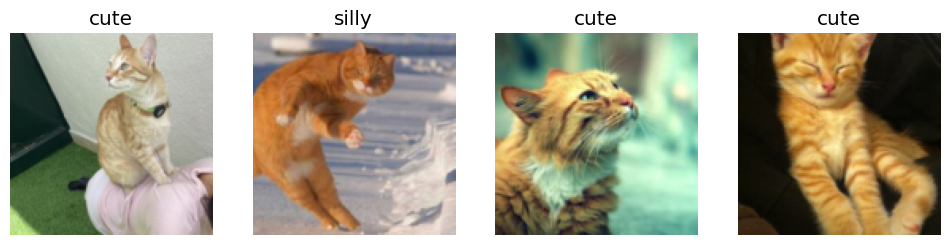

In [35]:
dls.valid.show_batch(max_n=4, nrows=1)

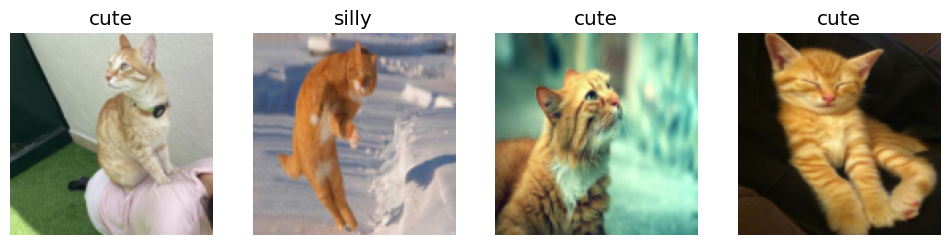

In [36]:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Squish))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

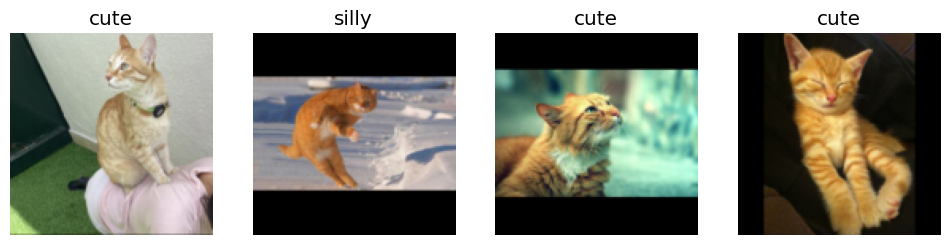

In [37]:
bears = bears.new(item_tfms=Resize(128, ResizeMethod.Pad, pad_mode='zeros'))
dls = bears.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

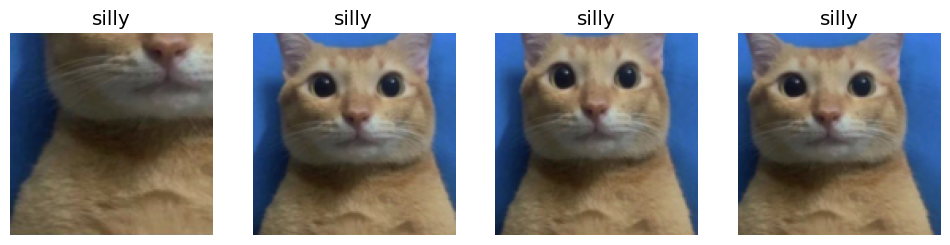

In [38]:
bears = bears.new(item_tfms=RandomResizedCrop(128, min_scale=0.3))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=4, nrows=1, unique=True)

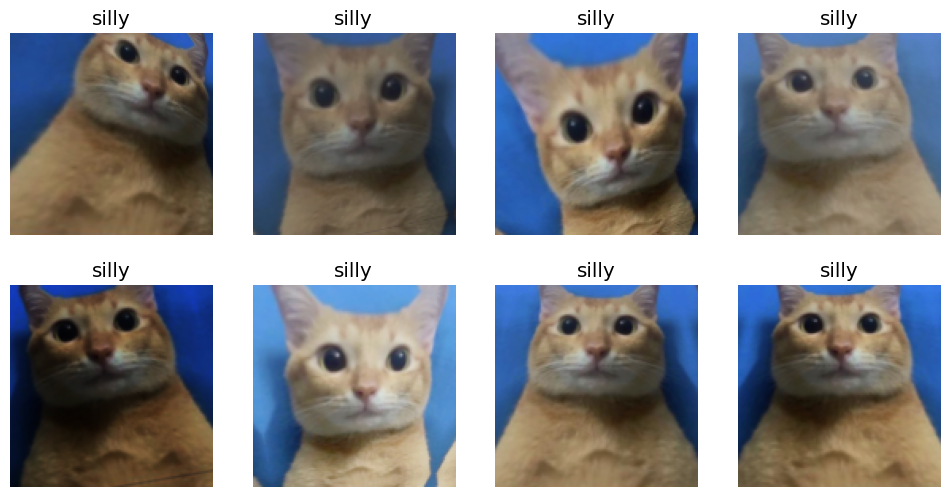

In [39]:
bears = bears.new(item_tfms=Resize(128), batch_tfms=aug_transforms(mult=2))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=8, nrows=2, unique=True)

In [40]:
bears = bears.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms())
dls = bears.dataloaders(path)

epoch,train_loss,valid_loss,error_rate,time
0,1.115525,1.849358,0.478261,00:03


epoch,train_loss,valid_loss,error_rate,time
0,1.073901,1.093935,0.434783,00:03
1,0.908420,0.700686,0.304348,00:04
2,0.858520,0.612039,0.304348,00:03
3,0.794238,0.629374,0.282609,00:03


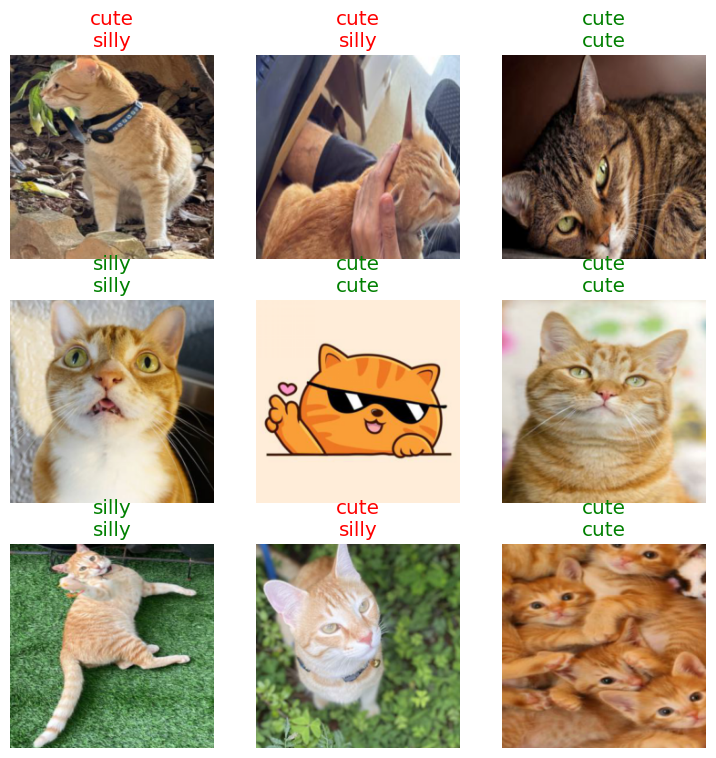

In [41]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)
learn.show_results()


Misclassified Examples:


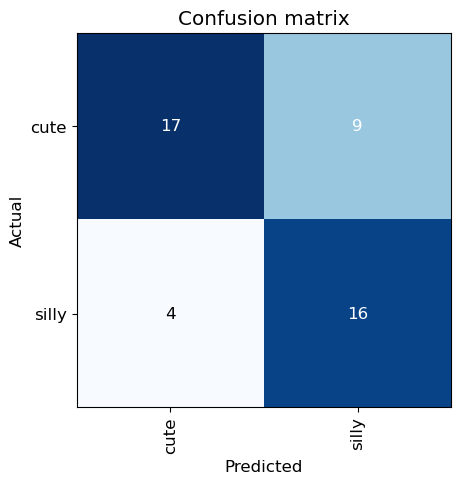

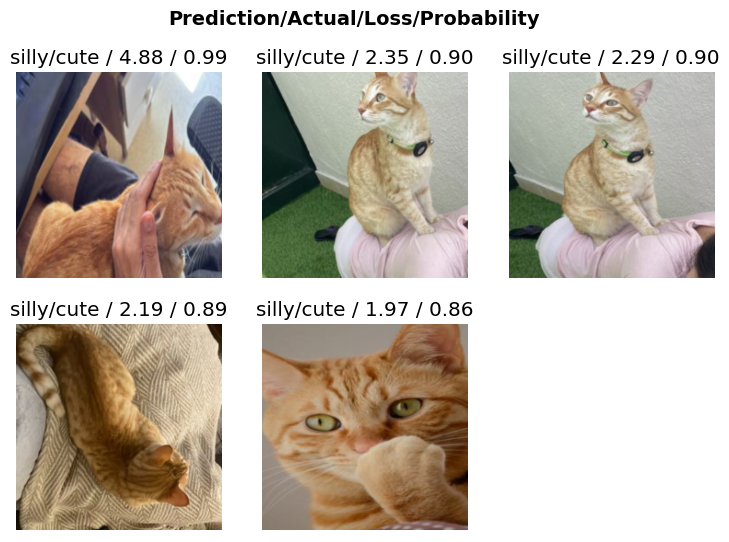

In [42]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

print("\nMisclassified Examples:")

interp.plot_top_losses(5, nrows=2)

In [43]:
from fastai.vision.widgets import ImageClassifierCleaner
cleaner = ImageClassifierCleaner(learn)
cleaner

In [44]:
# Take care. If this removes any images, the model will stop working.
for idx in cleaner.delete(): cleaner.fns[idx].unlink()
for idx,cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), path/cat)

In [45]:
import pathlib
temp = pathlib.PosixPath
pathlib.PosixPath = pathlib.WindowsPath

learn.export()

pathlib.PosixPath = temp  # Reset PosixPath to its original state

In [46]:
path = Path()
path.ls(file_exts='.pkl')

(#1) [Path('export.pkl')]

In [47]:
learn_inf = load_learner(path/'export.pkl')

In [48]:
learn_inf.predict('images/bear.jpg')

('silly', tensor(1), tensor([0.0156, 0.9844]))

In [49]:
learn_inf.dls.vocab

['cute', 'silly']